##✅ TASK 2: Exploratory Data Analysis (EDA)
Goal: Deeply analyze a dataset — find patterns, trends, and anomalies.

I'll use the Titanic dataset (classic, well-known, great for EDA (Exploratory Data Analysis)).

##Step 1 — Load the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load Titanic dataset directly from URL
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("✅ Dataset Loaded!")
print(f"Shape: {df.shape}")
df.head()

✅ Dataset Loaded!
Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


##Step 2 — Understand the Data Structure

In [2]:
# Basic info
print("=== Dataset Info ===")
print(df.info())

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== First 5 Rows ===")
df.head()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

=== Data Types ===
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket        

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


##Step 3 — Check Missing Values

=== Missing Values ===
          Missing Count  Missing %
Cabin               687  77.104377
Age                 177  19.865320
Embarked              2   0.224467


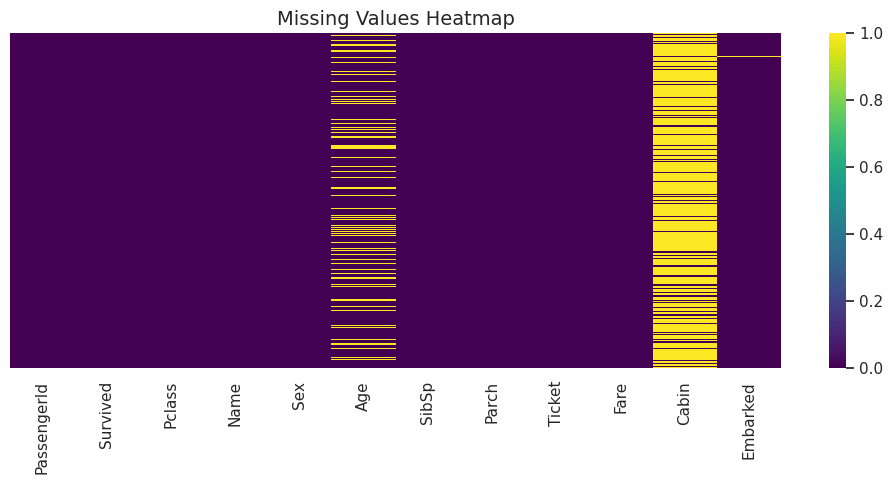

In [3]:
print("=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)
print(missing_df[missing_df['Missing Count'] > 0])

# Visualize missing values
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis')
plt.title('Missing Values Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('missing_values.png', dpi=150)
plt.show()

##Step 4 — Statistical Summary

In [4]:
print("=== Statistical Summary ===")
df.describe().round(2)

=== Statistical Summary ===


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


##Step 5 — Data Cleaning

In [5]:
# Fill missing Age with median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Fill missing Embarked with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop Cabin (too many missing values)
df.drop(columns=['Cabin'], inplace=True)

# Create new features
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
df['AgeGroup'] = pd.cut(df['Age'],
                         bins=[0, 12, 18, 35, 60, 100],
                         labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])

print("✅ Cleaning done! New shape:", df.shape)

✅ Cleaning done! New shape: (891, 14)


##Step 6 — Key Analysis Questions

In [6]:
# Q1: Overall survival rate
print(f"Overall Survival Rate: {df['Survived'].mean()*100:.1f}%")

# Q2: Survival by gender
print("\nSurvival by Gender:")
print(df.groupby('Sex')['Survived'].mean().mul(100).round(1).astype(str) + '%')

# Q3: Survival by class
print("\nSurvival by Passenger Class:")
print(df.groupby('Pclass')['Survived'].mean().mul(100).round(1).astype(str) + '%')

# Q4: Average age of survivors vs non-survivors
print("\nAverage Age:")
print(df.groupby('Survived')['Age'].mean().round(1))

Overall Survival Rate: 38.4%

Survival by Gender:
Sex
female    74.2%
male      18.9%
Name: Survived, dtype: object

Survival by Passenger Class:
Pclass
1    63.0%
2    47.3%
3    24.2%
Name: Survived, dtype: object

Average Age:
Survived
0    30.0
1    28.3
Name: Age, dtype: float64


##Step 7 — Visualizations

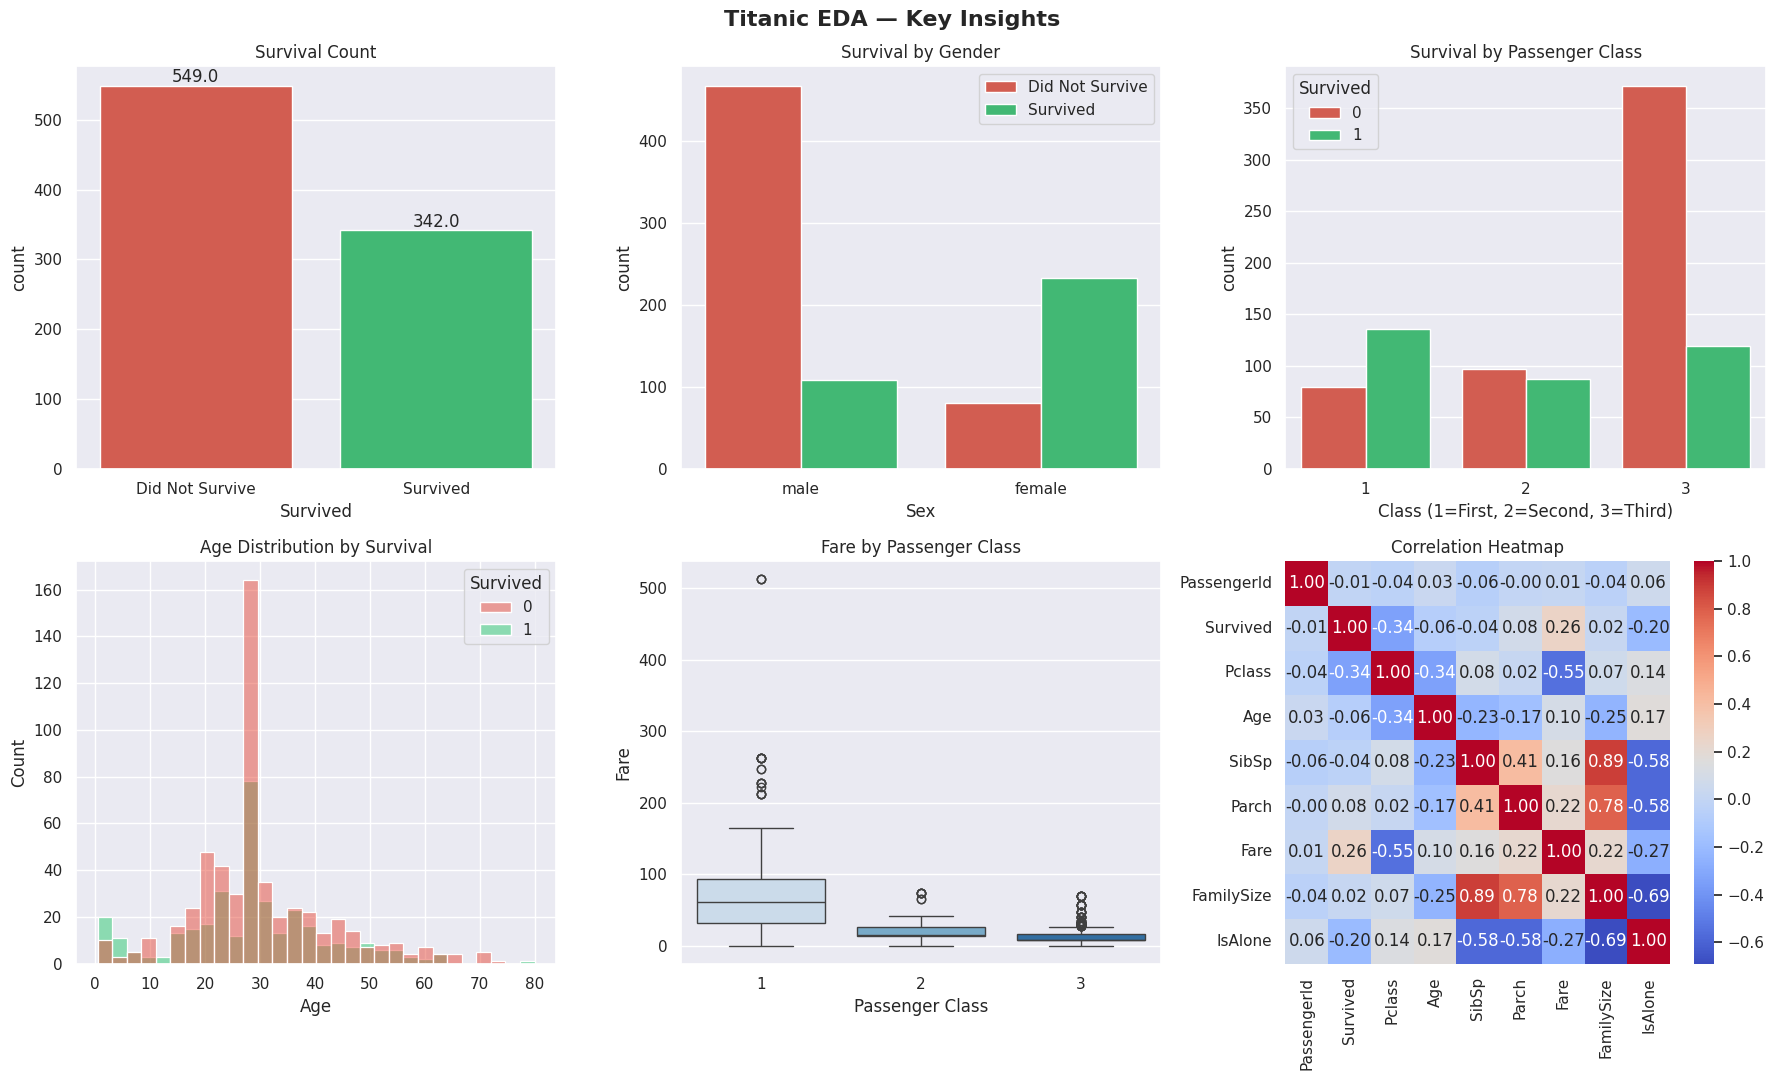

✅ EDA Visualizations saved!


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Titanic EDA — Key Insights', fontsize=16, fontweight='bold')

# 1. Survival count
sns.countplot(x='Survived', data=df, palette=['#e74c3c', '#2ecc71'], ax=axes[0,0])
axes[0,0].set_title('Survival Count')
axes[0,0].set_xticklabels(['Did Not Survive', 'Survived'])
for p in axes[0,0].patches:
    axes[0,0].annotate(f'{p.get_height()}', (p.get_x()+0.3, p.get_height()+5))

# 2. Survival by gender
sns.countplot(x='Sex', hue='Survived', data=df,
              palette=['#e74c3c', '#2ecc71'], ax=axes[0,1])
axes[0,1].set_title('Survival by Gender')
axes[0,1].legend(['Did Not Survive', 'Survived'])

# 3. Survival by class
sns.countplot(x='Pclass', hue='Survived', data=df,
              palette=['#e74c3c', '#2ecc71'], ax=axes[0,2])
axes[0,2].set_title('Survival by Passenger Class')
axes[0,2].set_xlabel('Class (1=First, 2=Second, 3=Third)')

# 4. Age distribution
sns.histplot(data=df, x='Age', hue='Survived', bins=30,
             palette=['#e74c3c', '#2ecc71'], ax=axes[1,0])
axes[1,0].set_title('Age Distribution by Survival')

# 5. Fare distribution
sns.boxplot(x='Pclass', y='Fare', data=df, palette='Blues', ax=axes[1,1])
axes[1,1].set_title('Fare by Passenger Class')
axes[1,1].set_xlabel('Passenger Class')

# 6. Correlation heatmap
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', ax=axes[1,2])
axes[1,2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA Visualizations saved!")

##Step 8 — Key Findings Summary

In [8]:
print("""
╔══════════════════════════════════════════════════════╗
║           EDA KEY FINDINGS — TITANIC DATASET         ║
╠══════════════════════════════════════════════════════╣
║  • Overall survival rate: ~38%                       ║
║  • Women survived at 74% vs Men at only 19%          ║
║  • 1st class passengers had highest survival rate    ║
║  • Children had better survival chances              ║
║  • Higher fare = higher survival probability         ║
║  • Traveling alone slightly lowered survival odds    ║
╚══════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════╗
║           EDA KEY FINDINGS — TITANIC DATASET         ║
╠══════════════════════════════════════════════════════╣
║  • Overall survival rate: ~38%                       ║
║  • Women survived at 74% vs Men at only 19%          ║
║  • 1st class passengers had highest survival rate    ║
║  • Children had better survival chances              ║
║  • Higher fare = higher survival probability         ║
║  • Traveling alone slightly lowered survival odds    ║
╚══════════════════════════════════════════════════════╝

